In [1]:
# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, LinearSegmentedColormap

In [2]:
# Read in data, here top drugs for each protein
df = pd.read_csv('data/top_protein_drugs_score_matrix.csv',index_col=0)

In [3]:
# Sort each row in descending order (largest values first)
sorted_values = np.sort(df.to_numpy(dtype=float), axis=1)[:, ::-1]

# Convert back to DataFrame with rank-based column names
df_row_sorted = pd.DataFrame(
    sorted_values,
    index=df.index,
    columns=[f"rank_{i+1}" for i in range(df.shape[1])]
)

# Order proteins by their top (rank_1) value
protein_order = np.argsort(df_row_sorted.iloc[:, 0].to_numpy())[::-1]
df_final = df_row_sorted.iloc[protein_order]

# Count number of zero values per protein
zero_counts = (df_final == 0).sum(axis=1)

# Remove proteins with too many zeros
df_final = df_final[zero_counts <= 100]

# Remove columns (ranks) that are mostly zeros
df_subset = df_final.loc[:, (df_final == 0).mean(axis=0) <= 0.75]

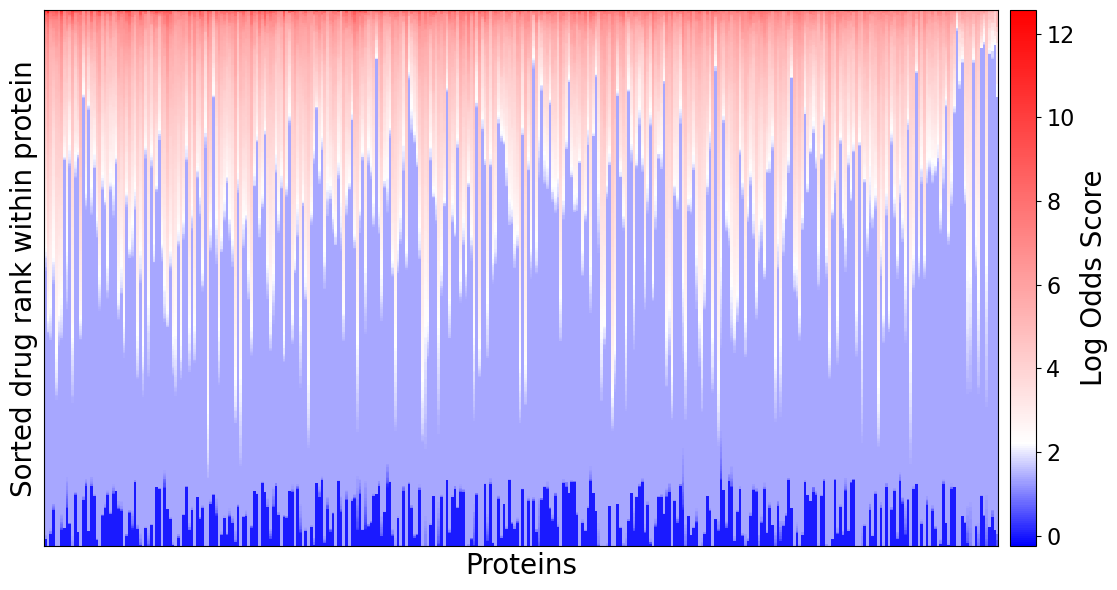

In [4]:
# Plot
plt.figure(figsize=(12, 6))

# Convert data to numpy for min/max calculations
data = df_final.to_numpy()
vmin = np.nanmin(data)
vmax = np.nanmax(data)
vcenter = 2.197  # value that should map to white

# Compute relative position of center within the range
p = (vcenter - vmin) / (vmax - vmin)
p = np.clip(p, 0, 1)  # ensure it stays within valid bounds

# Create custom blue–white–red colormap with white at vcenter
cmap = LinearSegmentedColormap.from_list(
    "custom_bwr",
    [
        (0.0, "blue"),
        (p, "white"),
        (1.0, "red"),
    ]
)

# Normalize color scaling across full data range
norm = Normalize(vmin=vmin, vmax=vmax)

# Plot heatmap (transpose so ranks are on y-axis)
im = plt.imshow(
    df_subset.T,
    aspect='auto',
    cmap=cmap,
    norm=norm,
    interpolation='nearest'
)

# Add colorbar
cbar = plt.colorbar(im, label='Log Odds Score', pad=0.01)
cbar.set_label(label='Log Odds Score', fontsize=20)
cbar.ax.tick_params(labelsize=16)

# Axis labels and formatting
plt.xlabel('Proteins', fontsize=20)
plt.ylabel('Sorted drug rank within protein', fontsize=20)
plt.xticks([])
plt.yticks([])

# Show plot
plt.tight_layout()
plt.show()